# Analysis of Control nodes (In progress)

#### Done

1. From node communities data, find out the  time spent in sync cluster for each node
2. From connectivity data, find the out degree
3. Calculate median time spent for 200 iterations (as of now)


#### In progress

1. Consider those nodes which have
    
    A. High out degree but low median time
    
    B. Low out degree but high median time
2. Move the connector hub code to 'Analysis Centrality.ipynb'
#### To ask:
1. Use of directed graph made out of symmetric connectivity matrix


In [ ]:
%reload_ext autoreload
%autoreload 2

import networkx as nx
import numpy as np
import pandas as pd 
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from tes.DataUtils import DataUtils


#### Finding out degree using functionin DataUtils

In [13]:
l=DataUtils()
analyse = AnalysisFunc()
reader = DataRead()


../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


In [3]:
df_nc=reader.data_read_bz2('raw/FN/nc_200.bz2')

df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')


In [4]:
pm=analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


In [5]:
# can get directly the out degree
l.OUT_DEGREE.shape

(426,)

In [23]:
l.WHOLE_BRAIN_CONN.shape
# here G is the directed graph
G = nx.from_numpy_array(l.WHOLE_BRAIN_CONN, create_using=nx.DiGraph())
out_degree_dict = dict(G.out_degree())

In [88]:
type(l.WHOLE_BRAIN_CONN)
f=l.WHOLE_BRAIN_CONN
f_T=l.WHOLE_BRAIN_CONN.T

In [91]:
#### Checking if whole brain conn matrix is symmetric or unsymmetric

In [92]:
f[36,213]

0.0016204648885519857

In [95]:
f_T[213,36]

0.0016204648885519857

In [94]:
if f.all() == f_T.all():
    print('True')

True


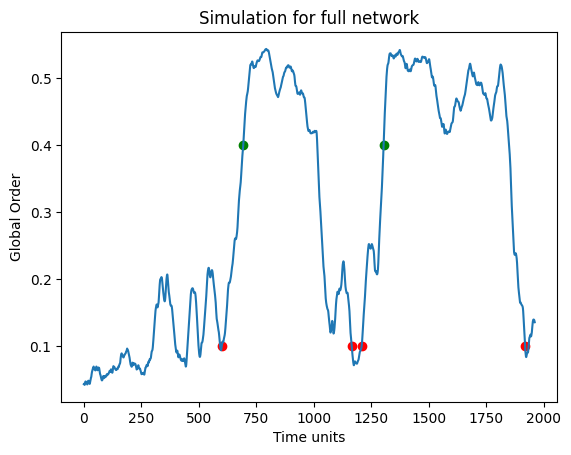

In [7]:
analyse.plot_global_synchrony(df_itr[77],0.05)

#### Compute time spent in main cluster

In [8]:
ts=analyse.compute_time_spent_mc(df_nc.loc[3])
type(ts)
dum=ts

#### Calculating MEDIAN time spent for whole node communities data

STEPS:
1. Take a 5000 x 426 dataframe
2. Calculate time spennt in MC for each node using compute_time_spent_mc function
3. Find such list of length 426 for each 5000 x 426 node community data
4. Store these list in dataframes of column 426
5. Then take median for every column to get the median time spent for any node


In [9]:
df_r=df_nc.reset_index(drop=True)

In [10]:
i=0
f=5000
time_list=[]
node_list=[]
while f < df_r.shape[0]:
    l=analyse.compute_time_spent_mc(df_r.iloc[i:f,:])
    node_list.append(l)
    i=f
    f+=5000

df_time_spent = pd.DataFrame(node_list)
df_time_spent.shape




(127, 426)

In [11]:
# calculate median of every column
MTS = df_time_spent.median()
med_time_spent = list(MTS)
keys=list(range(0,426))
mts_dict=dict(zip(keys,med_time_spent))
mts_sorted =dict(sorted(mts_dict.items(), key=lambda item: item[1]))

In [14]:
out_degree=list(l.OUT_DEGREE)
out_deg_dict=dict(zip(keys,out_degree))
out_deg_sort=dict(sorted(out_deg_dict.items(), key=lambda item: item[1]))

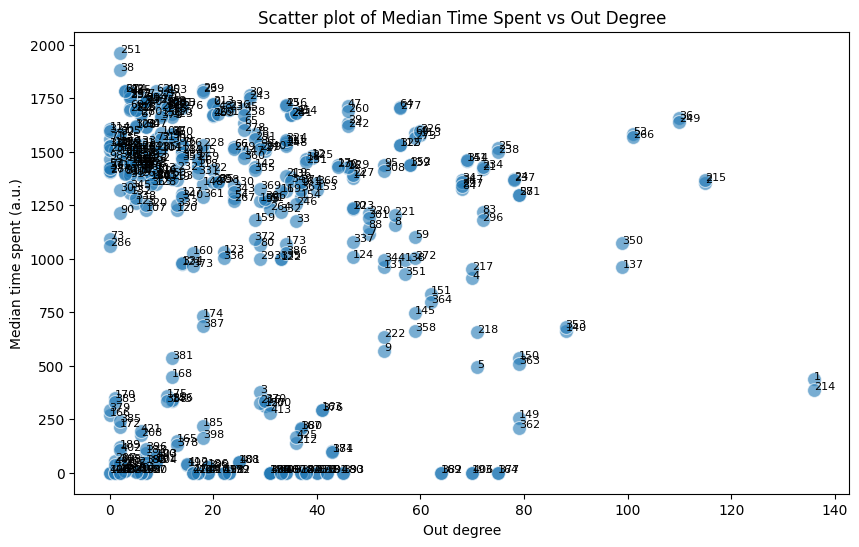

In [22]:

node_numbers = keys
# Create the scatter plot
plt.figure(figsize=(10, 6))
ax=sns.scatterplot(x=out_degree, y=med_time_spent, s=100, alpha=0.6, edgecolor='w')

# Annotate points with node numbers
for i, txt in enumerate(node_numbers):
    ax.annotate(txt, (out_degree[i], med_time_spent[i]), fontsize=8)
# Add labels and title

# plt.xlim(0, 40)  # Adjust the range as needed
# plt.ylim(1700,2000)  
plt.xlabel('Out degree')
plt.ylabel('Median time spent (a.u.)')
plt.title('Scatter plot of Median Time Spent vs Out Degree')

# Show the plot
plt.show()


#### Analysing network measures, move below sections in Analysis Centrality notebook
1. Computing connector hubs : Nodes with high degree and high betweenness centrality

In [53]:
# Degree centrality
degree_centrality = nx.degree_centrality(G)

# Betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)

# Eigenvector centrality (optional)
eigenvector_centrality = nx.eigenvector_centrality(G)

# Sort nodes by centrality measures
top_degree_centrality = dict(sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True))
top_betweenness_centrality = dict(sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True))




In [ ]:
# use undirected graph

In [54]:
type(top_degree_centrality)

dict

In [71]:
list(reader.data_read_pkl('raw/betw.pkl').keys())[0:10]

[214, 1, 137, 350, 2, 215, 36, 249, 266, 53]

In [66]:
deg_cent_sorted =list(top_degree_centrality.keys())[0:20]
print(deg_cent_sorted)

[1, 214, 2, 137, 215, 350, 36, 249, 53, 266, 149, 362, 140, 150, 151, 353, 363, 364, 169, 382]


In [67]:
bet_cent_sorted = list(top_betweenness_centrality.keys())[0:20]
print(bet_cent_sorted)

[350, 137, 326, 113, 297, 84, 167, 380, 95, 308, 301, 88, 266, 53, 141, 354, 149, 362, 353, 140]


In [64]:
common_node = list(set(deg_cent_sorted) & set(bet_cent_sorted))

In [65]:
common_node

[353, 137, 266, 362, 140, 53, 149, 350]

#### Using graph made in MBN_resconstraint

In [72]:
G = nx.from_numpy_array(l.WHOLE_BRAIN_CONN)
avg_degree = (sum(dict(G.degree()).values())/l.N_REGIONS_WHOLE_BRAIN)
A = np.mat(nx.adjacency_matrix(G).todense())
np.fill_diagonal(A, 0)

In [74]:
type(A)
A.shape

(426, 426)

In [76]:
bet_cent = nx.betweenness_centrality(G)
type(bet_cent)

dict

In [77]:
top_bet_cent_sort= dict(sorted(bet_cent.items(), key=lambda x: x[1], reverse=True))

In [80]:
top_betweenness_centrality

{350: 0.02542180212751186,
 137: 0.025421802127511845,
 326: 0.02038527243784003,
 113: 0.020385272437840014,
 297: 0.01660004052142914,
 84: 0.016600040521429126,
 167: 0.01655209678733433,
 380: 0.01655209678733433,
 95: 0.015651438419114618,
 308: 0.01565143841911461,
 301: 0.015399252132070962,
 88: 0.01539925213207095,
 266: 0.014681669055254417,
 53: 0.014681669055254412,
 141: 0.014484775601293949,
 354: 0.014484775601293931,
 149: 0.013985964560889878,
 362: 0.013985964560889878,
 353: 0.013531749112939332,
 140: 0.013531749112939325,
 36: 0.01338409357220076,
 249: 0.013384093572200755,
 215: 0.013079331938660595,
 2: 0.01307933193866058,
 212: 0.012001346617244944,
 425: 0.012001346617244944,
 374: 0.011942526051984429,
 161: 0.011942526051984419,
 169: 0.011867538313248554,
 382: 0.01186753831324855,
 386: 0.011856504098111125,
 173: 0.011856504098111113,
 364: 0.011672808403976654,
 151: 0.01167280840397665,
 21: 0.01029076985229783,
 234: 0.010290769852297823,
 193: 0.0099

In [79]:
top_bet_cent_sort

{214: 0.024213330492729394,
 1: 0.024213330492729373,
 137: 0.021876077588668236,
 350: 0.021876077588668195,
 2: 0.020510702767149613,
 215: 0.020510702767149596,
 36: 0.018279655930717145,
 249: 0.018279655930717127,
 266: 0.015142250584322609,
 53: 0.015142250584322597,
 95: 0.013564637551595747,
 308: 0.013564637551595742,
 171: 0.012541801460616975,
 384: 0.012541801460616975,
 164: 0.011518320322701427,
 377: 0.011518320322701423,
 167: 0.011460476522006387,
 380: 0.011460476522006387,
 326: 0.010066720839503631,
 113: 0.01006672083950362,
 353: 0.009947271885857192,
 140: 0.009947271885857182,
 354: 0.009218128146509706,
 141: 0.009218128146509703,
 297: 0.009056569633493664,
 84: 0.009056569633493662,
 149: 0.008944551377672819,
 362: 0.008944551377672819,
 193: 0.008407954383873614,
 406: 0.008407954383873609,
 60: 0.008030324632334726,
 273: 0.008030324632334726,
 83: 0.007454689230716267,
 296: 0.00745468923071626,
 161: 0.007372440473168873,
 374: 0.007372440473168871,
 363